In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('/workspace/data/metrics.csv', parse_dates=['timestamp'])
df = df.set_index('timestamp').sort_index()
print(df.shape)
df.head()

(2570, 8)


,cpu_percent,mem_used_gb,mem_available_gb,disk_read_mb,disk_write_mb,gpu_util_percent,gpu_mem_used_gb,gpu_mem_total_gb
timestamp,,,,,,,,
2026-05-08 14:52:30.524861,2.4,10.94,19.55,236697.65,495900.29,18,1.79,8.0
2026-05-08 14:53:31.527647,2.3,10.90,19.60,236698.18,495910.35,5,1.84,8.0
2026-05-08 14:54:44.985898,2.1,11.30,19.20,236698.32,495931.30,11,1.82,8.0
2026-05-08 14:55:45.988675,3.6,10.90,19.60,236733.32,495954.99,23,1.82,8.0
2026-05-08 14:56:46.990606,4.3,11.18,19.32,236734.07,495979.92,17,1.83,8.0


In [2]:
# Disk deltas (same pattern as EDA)
df['disk_read_delta'] = df['disk_read_mb'].diff().clip(lower=0)
df['disk_write_delta'] = df['disk_write_mb'].diff().clip(lower=0)

# Memory utilization %
df['mem_util_percent'] = (df['mem_used_gb'] / (df['mem_used_gb'] + df['mem_available_gb'])) * 100

df = df.dropna()

print(df.shape)

(2569, 11)


In [3]:
features = [
    'cpu_percent',
    'mem_util_percent',
    'gpu_util_percent',
    'gpu_mem_used_gb',
    'disk_read_delta',
    'disk_write_delta'
]

x = df[features].copy()
x.describe()

,cpu_percent,mem_util_percent,gpu_util_percent,gpu_mem_used_gb,disk_read_delta,disk_write_delta
count,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000,2569.000000
mean,2.796575,43.958229,21.784352,2.128789,16.084079,33.557357
std,3.197973,6.251686,13.573277,0.552200,164.967956,183.553395
min,1.100000,34.240735,0.000000,1.610000,0.000000,5.140000
25%,1.600000,40.655738,11.000000,1.990000,0.000000,13.460000
50%,1.800000,42.163934,23.000000,2.080000,0.020000,17.540000
75%,2.200000,44.539193,27.000000,2.090000,0.150000,22.890000
max,99.800000,65.442623,100.000000,7.410000,3579.240000,3332.140000


In [4]:
iso_forest = IsolationForest(
    contamination=0.03,
    random_state=42,
    n_estimators=100
)

df['anomaly_score'] = iso_forest.fit_predict(x)
df['anomaly'] = df['anomaly_score'] == -1

print(f"Total anomalies flagged: {df['anomaly'].sum()}")
print(f"Anomaly rate: {df['anomaly'].mean():.2%}")

Total anomalies flagged: 78
Anomaly rate: 3.04%


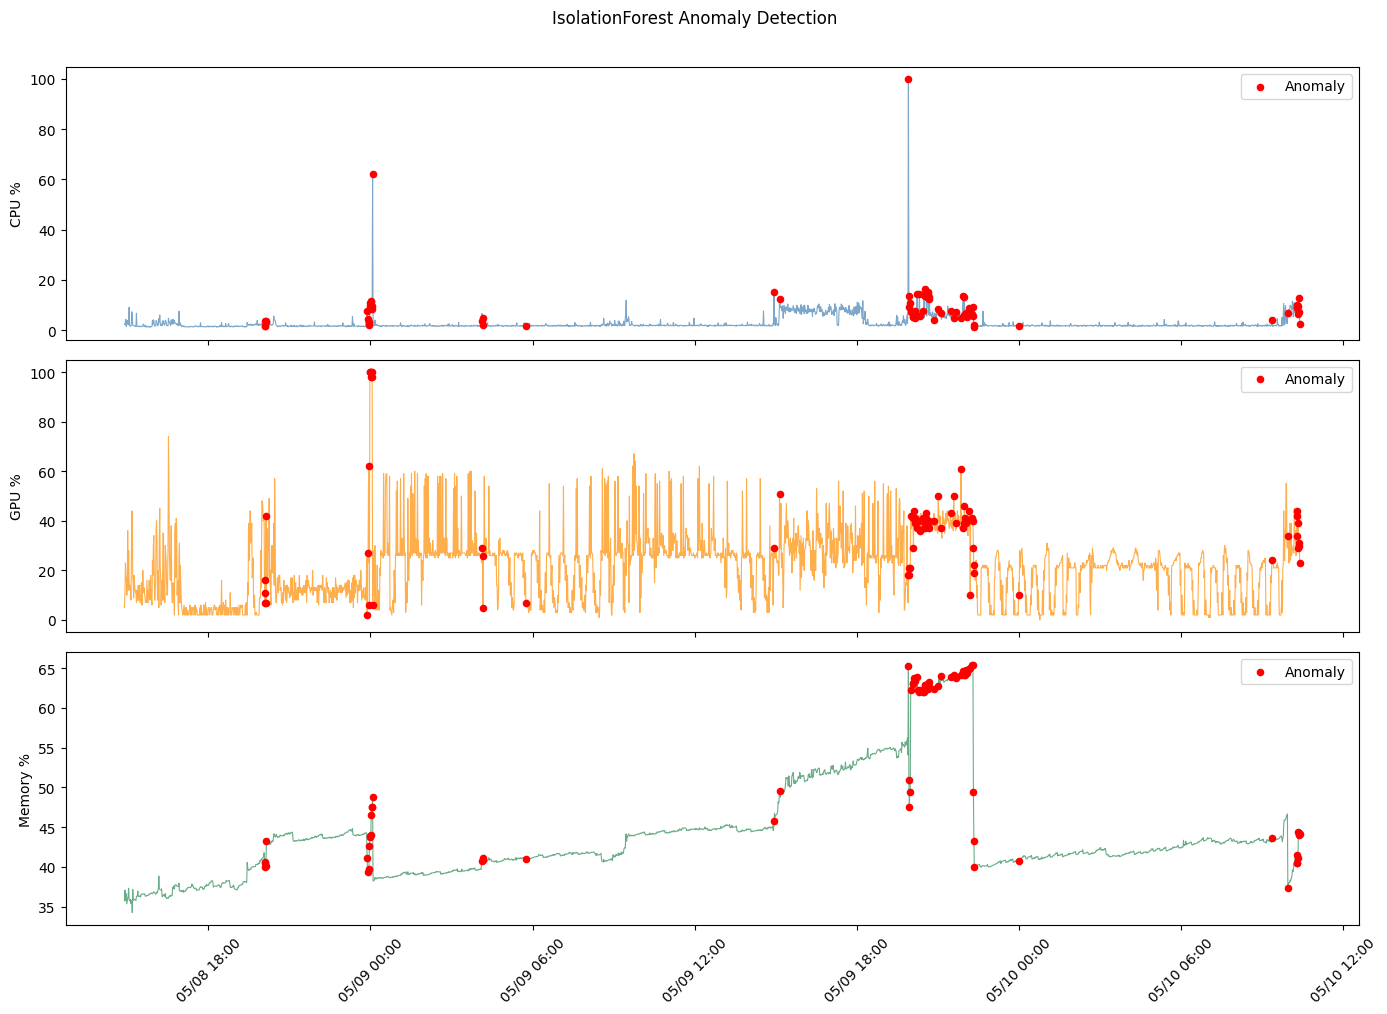

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14,10), sharex=True)

metrics_to_plot = [
    ('cpu_percent', 'CPU %', 'steelblue'),
    ('gpu_util_percent', 'GPU %', 'darkorange'),
    ('mem_util_percent', 'Memory %', 'seagreen')
]

for ax, (metric, label, color) in zip(axes, metrics_to_plot):
    ax.plot(df.index, df[metric], color=color, linewidth=0.8, alpha=0.7)
    ax.scatter(
        df.index[df['anomaly']],
        df[metric][df['anomaly']],
        color='red', s=20, zorder=5, label='Anomaly'
    )
    ax.set_ylabel(label)
    ax.legend(loc='upper right')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
plt.xticks(rotation=45)
plt.suptitle('IsolationForest Anomaly Detection', y=1.01)
plt.tight_layout()
plt.show()

In [7]:
df[df['anomaly']][features + ['anomaly_score']].describe()

,cpu_percent,mem_util_percent,gpu_util_percent,gpu_mem_used_gb,disk_read_delta,disk_write_delta,anomaly_score
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.0
mean,9.824359,53.410504,37.628205,3.372308,471.164615,485.466795,-1.0
std,12.683236,10.437852,22.163565,1.284867,829.627721,950.721034,0.0
min,1.400000,37.323713,2.000000,1.800000,0.040000,8.820000,-1.0
25%,4.925000,43.221311,26.250000,2.092500,22.822500,18.662500,-1.0
50%,7.500000,56.459016,39.000000,3.815000,66.850000,31.540000,-1.0
75%,12.025000,63.332240,41.750000,4.200000,446.035000,300.540000,-1.0
max,99.800000,65.442623,100.000000,7.410000,3579.240000,3332.140000,-1.0


## Observations

- Correlated CPU+GPU spikes (WhisperX, gaming) are the most visually obvious anomalies
- IsolationForest also correctly identifies high disk I/O events independent of compute load
- Scattered anomalies during low-compute periods are primarily driven by disk_read_delta and disk_write_delta
- This demonstrates IsolationForest's ability to detect anomalies across multiple feature dimensions simultaneously

In [8]:
from scipy import stats

z_scores = np.abs(stats.zscore(x))
df['zscore_anomaly'] = (z_scores > 3).any(axis=1)

print(f"Z-score anomalies flagged: {df['zscore_anomaly'].sum()}")
print(f"Z-score anomaly rate: {df['zscore_anomaly'].mean():.2%}")

Z-score anomalies flagged: 171
Z-score anomaly rate: 6.66%


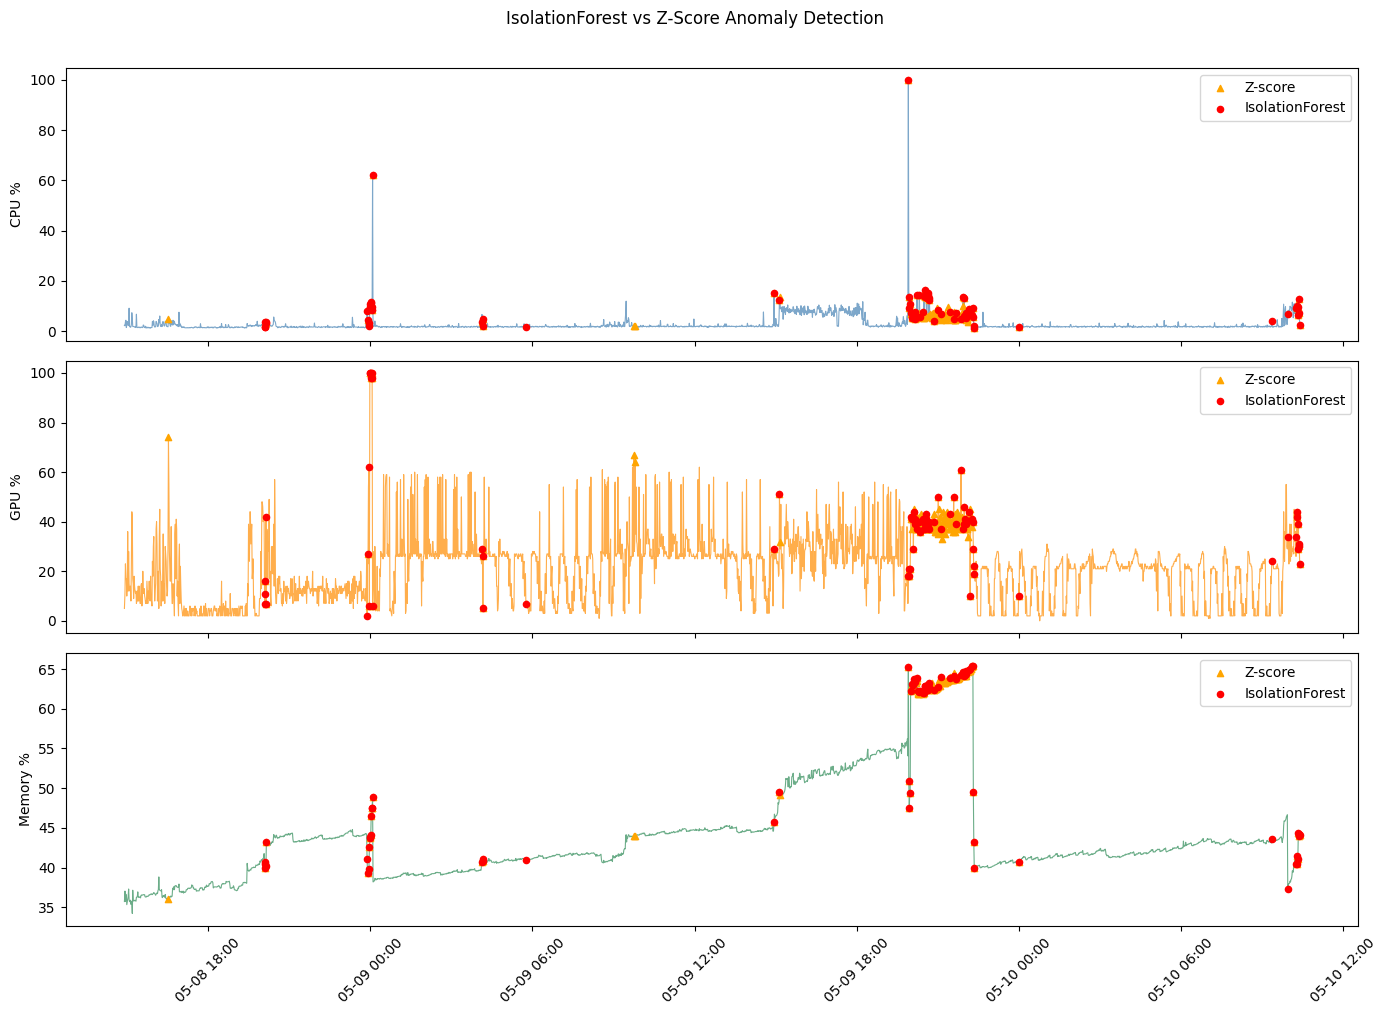

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

metrics_to_plot = [
    ('cpu_percent', 'CPU %', 'steelblue'),
    ('gpu_util_percent', 'GPU %', 'darkorange'),
    ('mem_util_percent', 'Memory %', 'seagreen')
]

for ax, (metric, label, color) in zip(axes, metrics_to_plot):
    ax.plot(df.index, df[metric], color=color, linewidth=0.8, alpha=0.7)
    ax.scatter(df.index[df['zscore_anomaly']], df[metric][df['zscore_anomaly']],
               color='orange', s=20, zorder=4, label='Z-score', marker='^')
    ax.scatter(df.index[df['anomaly']], df[metric][df['anomaly']],
               color='red', s=20, zorder=5, label='IsolationForest', marker='o')
    ax.set_ylabel(label)
    ax.legend(loc='upper right')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.suptitle('IsolationForest vs Z-Score Anomaly Detection', y=1.01)
plt.tight_layout()
plt.show()

## Z-Score vs IsolationForest

Z-score flags 171 points (6.66%) vs IsolationForest's 78 (3.04%).

Z-score evaluates each metric independently against a global mean — 
making it sensitive to baseline shifts over time and single-metric spikes 
that may not represent genuinely unusual system states.

IsolationForest considers the full feature combination, making it more 
robust to single-metric variation and better at identifying truly unusual 
system states across multiple dimensions simultaneously.

In [10]:
both = (df['anomaly'] & df['zscore_anomaly']).sum()
iso_only = (df['anomaly'] & ~df['zscore_anomaly']).sum()
zscore_only = (~df['anomaly'] & df['zscore_anomaly']).sum()

print(f"Flagged by both:           {both}")
print(f"IsolationForest only:      {iso_only}")
print(f"Z-score only:              {zscore_only}")
print(f"Agreement rate:            {both / df['anomaly'].sum():.2%} of IF anomalies confirmed by z-score")

Flagged by both:           68
IsolationForest only:      10
Z-score only:              103
Agreement rate:            87.18% of IF anomalies confirmed by z-score


## Summary

- 68 high-confidence anomalies flagged by both methods
- 10 IsolationForest-only anomalies — unusual feature combinations 
  not detectable by single-metric thresholding
- 103 Z-score-only anomalies — likely false positives driven by 
  baseline drift and single-metric spikes

For production anomaly detection on this system, IsolationForest 
provides a more actionable signal with fewer false positives.

An interesting note: neither method flagged the rising Memory usage over time.
Firefox slowly uses more and more memory over time and can lead to memory issues
Clear in the graph but undetected by the analysis